In [1]:
geo_path = '/eos/user/j/jrimmer/Geometry'
import sys
sys.path.insert(0, geo_path)
sys.path.insert(0, "../")
sys.path.insert(0, "../scripts")
sys.path.insert(0, "../LicketyFit")
from Geometry.Device import Device

from LicketyFit.Event import *
from LicketyFit.PMT import *

from LicketyFit.Emitter import *

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import uproot, json, awkward as ak
from read_sim_data import *
from plot_event import *

with open('/eos/user/j/jrimmer/SWAN_projects/beam/LicketyFit2/tables/other_mpmt_info_v2.dict', 'rb') as f:
    mpmt_info = pickle.load(f)
    
from particle_range_lookup import *

In [2]:
folder = "/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/p+/1kp+_1000MeV_x0y0zn1350.npz"
folder = "/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/p+/1kp+_800MeV_x0y0zn1348.npz"
#folder = "/eos/user/j/jrimmer/sim_work_dir/WCSim/wcsim.npz"
# Get the mapping between wcsim and wcte PMT positions
wcte_mapping = np.loadtxt('../tables/wcsim_wcte_mapping.txt')

# wcsim uses positions 1-19, so have to subtract 1 in the mapping...
sim_wcte_mapping = {}
for i in range(len(wcte_mapping)):
    sim_wcte_mapping[int(wcte_mapping[i][0])] = int(wcte_mapping[i][1]*100 + wcte_mapping[i][2] - 1)
    
    
data_raw = read_sim_data(folder)

In [3]:
url = folder
fname = '/eos/user/j/jrimmer/sim_work_dir/WCSim/sim_data/p+/1kp+_800MeV_x0y0zn1348.root'
#fname = '/eos/user/j/jrimmer/sim_work_dir/WCSim/wcsim.root'
# se_name = "secondary_electron"
# sep_name = 'secondary_e_photons'
ck_name = 'ck_step'
all_name = 'all_photons'
n = 2000000   # number of entries to load

# Get the mapping between wcsim and wcte PMT positions
wcte_mapping = np.loadtxt('../tables/wcsim_wcte_mapping.txt')

with uproot.open(fname) as f:
#     t = f[se_name]
#     arr = t.arrays(library="ak", entry_stop=n)
    
#     t_sep = f[sep_name]
#     arr_sep = t_sep.arrays(library="ak", entry_stop=n)
    
    t_ck = f[ck_name]
    arr_ck = t_ck.arrays(library="ak", entry_stop=n)
    
#     t_all = f[all_name]
#     arr_all = t_all.arrays(library="ak", entry_stop=n)

# df_se = ak.to_dataframe(arr).reset_index(drop=True)
# df_sep = ak.to_dataframe(arr_sep).reset_index(drop=True)
df_ck = ak.to_dataframe(arr_ck).reset_index(drop=True)
# df_all = ak.to_dataframe(arr_all).reset_index(drop=True)

In [4]:
df_ck[df_ck['event']==43]

,event,trackID,step,pdg,n_ck,x,y,z,t,ke,ke_pre,ke_post,edep,step_len,mat,step_proc
8696,43,1,1,2212,90,0.000000,-42.476299,-134.800003,0.000000,799.543579,800.000000,799.543579,0.456407,0.244825,Water,Cerenkov
8697,43,1,2,2212,98,0.000000,-42.476299,-134.555176,0.009701,799.069153,799.543579,799.069153,0.474413,0.244994,Water,Cerenkov
8698,43,1,3,2212,119,-0.000008,-42.476181,-134.310181,0.019410,798.637329,799.069153,798.637329,0.431837,0.245170,Water,Cerenkov
8699,43,1,4,2212,116,-0.000018,-42.476215,-134.065018,0.029128,798.094543,798.637329,798.094543,0.542813,0.245330,Water,Cerenkov
8700,43,1,5,2212,106,-0.000181,-42.476254,-133.819687,0.038852,797.586243,798.094543,797.586243,0.508277,0.245533,Water,Cerenkov
8701,43,1,6,2212,0,-0.000162,-42.476730,-133.574142,0.048586,0.000000,797.586243,0.000000,0.320220,0.177771,Water,protonInelastic


In [46]:
pid_info = {
    -13: {
        "name": "mu+",
        "mass_MeV": 105.6583755,
    },
    11: {
        "name": "e-",
        "mass_MeV": 0.51099895069,
    },
    -11: {
        "name": "e+",
        "mass_MeV": 0.51099895069,
    },
    12: {
        "name": "nu_e",
        "mass_MeV": 0,
    },
    13: {
        "name": "mu",
        "mass_MeV": 105.56,
    },
    14: {
        "name": "nu_mu",
        "mass_MeV": 0,
    },
    -14: {
        "name": "nu_mu_bar",
        "mass_MeV": 0,
    },
    22: {
        "name": "gamma",
        "mass_MeV": 0.0,
    },
    211: {
        "name": "pi+",
        "mass_MeV": 139.57039,
    },
    -211: {
        "name": "pi-",
        "mass_MeV": 139.57039,
    },
    111: {
        "name": "pi0",
        "mass_MeV": 134.98,
    },
    2112: {
        "name": "neutron",
        "mass_MeV": 939.56542194,
    },
    2212: {
        "name": "proton",
        "mass_MeV": 938.27208943,
    },
    1000010020: {
        "name": "deuteron",
        "mass_MeV": 1875.612945,
    },
    1000080170: {
        "name": "O17 nucleus",
        "mass_MeV": 15830.505,  # approximate nuclear mass
    },
}

In [64]:
track_id_energy = []
energy_frac = []
num_top = 2

for i in range(len(data_raw['track_energy'])):
    mask = (np.array(data_raw['track_id'][i]) > 0) & (np.array(data_raw['track_start_time'][i]) < 20)
    
    pids = np.asarray(data_raw["track_pid"][i])[mask]
    
    pid_mass = np.array([pid_info[int(pid)]['mass_MeV'] for pid in pids])
    
    energies = np.asarray(data_raw["track_energy"][i])[mask] - pid_mass

    # indices of the largest 3 energies, sorted from largest to smallest
    idx_top3 = np.argsort(energies)[-num_top:][::-1]

    top3_energies = energies[idx_top3]
    
    top3_pid = np.asarray(data_raw["track_pid"][i])[mask][idx_top3]
    top3_id = np.asarray(data_raw["track_id"][i])[mask][idx_top3]
    
    p_idx = np.where(idx_top3==1)[0]
    
    evt_info = []
    for j in range(num_top):
        evt_info.extend([[top3_id[j],top3_pid[j],top3_energies[j]]])
    
    
    track_id_energy.append(evt_info)
    
    
track_id_energy = np.array(track_id_energy)

In [65]:
len(track_id_energy)

1000

In [76]:
not_p_energy_list = []
for i in range(len(track_id_energy)):
    print('Event',i)
    not_p_energy = 0
    for j in range(num_top):
        if track_id_energy[i][j][0] != 1:
            particle = pid_info[int(track_id_energy[i][j][1])]['name']
            ke = track_id_energy[i][j][2] 
            
            print("particle:",particle)
            print('ke:',ke)
            not_p_energy += ke
            
    not_p_energy_list.append([particle, not_p_energy])
            
    print('')

Event 0
particle: proton
ke: 741.887822679375

Event 1
particle: proton
ke: 329.15283732781245

Event 2
particle: neutron
ke: 271.04688274750004

Event 3
particle: proton
ke: 525.614873460625

Event 4
particle: proton
ke: 662.66003947625

Event 5
particle: neutron
ke: 326.29932415375004

Event 6
particle: proton
ke: 336.44727092156245

Event 7
particle: neutron
ke: 359.49695598968754

Event 8
particle: proton
ke: 717.124394945

Event 9
particle: proton
ke: 673.5527396715624

Event 10
particle: neutron
ke: 354.96411907562504

Event 11
particle: proton
ke: 60.8017020739062

Event 12
particle: proton
ke: 550.0258842028124

Event 13
particle: proton
ke: 569.1936088121874

Event 14
particle: neutron
ke: 232.33362591156254

Event 15
particle: proton
ke: 299.57105021843745

Event 16
particle: pi+
ke: 195.354658828125

Event 17
particle: proton
ke: 251.25122599968745

Event 18
particle: proton
ke: 442.80762248406245

Event 19
particle: proton
ke: 116.65051799187495

Event 20
particle: neutron


Text(0.5, 0, 'KE of Most Energetic Secondary (MeV)')

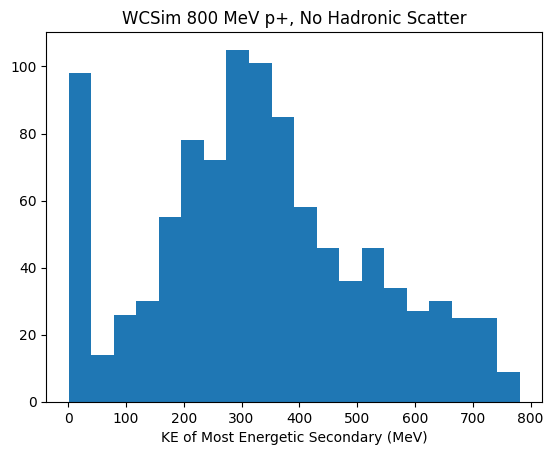

In [72]:
plt.hist(not_p_energy_list,bins =20);
plt.title('WCSim 800 MeV p+, No Hadronic Scatter')
plt.xlabel('KE of Most Energetic Secondary (MeV)')

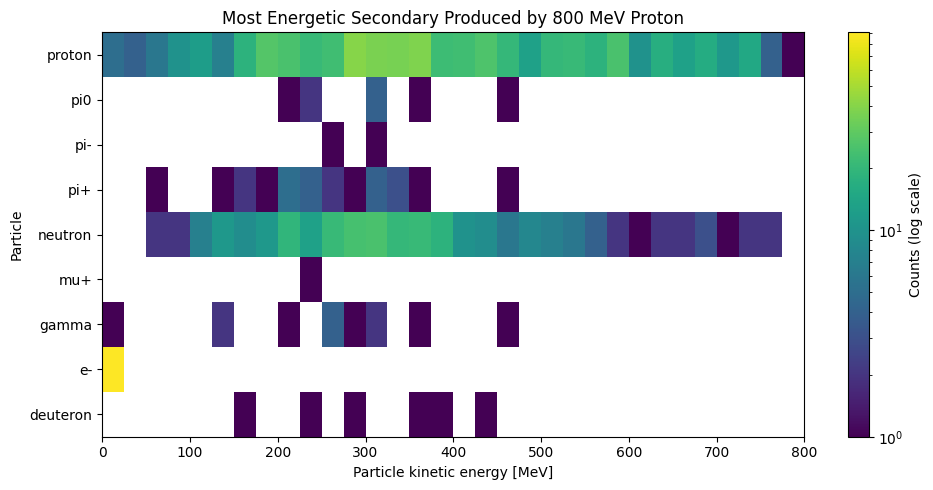

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

particle_names = np.array([x[0] for x in not_p_energy_list])
energies = np.array([float(x[1]) for x in not_p_energy_list])

unique_particles = sorted(np.unique(particle_names))

particle_to_y = {name: i for i, name in enumerate(unique_particles)}
y_vals = np.array([particle_to_y[name] for name in particle_names])

energy_bins = np.arange(0, np.max(energies) + 25, 25)
y_bins = np.arange(len(unique_particles) + 1) - 0.5

counts, x_edges, y_edges = np.histogram2d(
    energies,
    y_vals,
    bins=[energy_bins, y_bins]
)

# Log scale cannot display zeros, so mask zero-count bins
counts_for_plot = np.ma.masked_where(counts.T == 0, counts.T)

plt.figure(figsize=(10, 5))

plt.pcolormesh(
    x_edges,
    y_edges,
    counts_for_plot,
    shading="auto",
    norm=LogNorm()
)

plt.colorbar(label="Counts (log scale)")

plt.yticks(
    ticks=np.arange(len(unique_particles)),
    labels=unique_particles
)

plt.xlabel("Particle kinetic energy [MeV]")
plt.ylabel("Particle")
plt.title("Most Energetic Secondary Produced by 800 MeV Proton")

plt.tight_layout()
plt.show()

In [13]:
np.unique(track_id_energy[:,1])

array([-1.30000000e+01,  1.10000000e+01,  2.20000000e+01,  2.11000000e+02,
        2.11200000e+03,  2.21200000e+03,  1.00001002e+09,  1.00008017e+09])

In [97]:
OUTER_RING = np.array([0, 7, 19, 34, 50, 66, 82, 83, 105, 94, 95, 71, 72, 56, 40, 24, 11, 3, 18])
INNER_RING = np.array([1, 8, 35, 51, 67, 84, 69, 70, 55, 39, 23, 10, 2, 20, 36, 52, 68, 53, 54, 38, 22, 21, 37, 9])

#RING = np.concatenate([OUTER_RING, INNER_RING])
RING = INNER_RING
ALL_MPMTS = np.arange(0,106)

indices = []
max_evt = max(list(df_ck['event']))-1

vis_lengths = []

for i in range(max_evt):
    
    idx = np.where(data_raw['track_id'][i]==1)[0][0]
    
    dr = np.linalg.norm(data_raw['track_stop_position'][i][idx]-data_raw['track_start_position'][i][idx])*10
    dxdy = np.linalg.norm(data_raw['track_stop_position'][i][idx][:2]-data_raw['track_start_position'][i][idx][:2])*10
    
    mask = np.array(data_raw['digi_hit_time'][i])<17
    tot_hits = len(np.array(data_raw['digi_hit_pmt'][i])[mask])
   
    
    wcsim_pmts = [data_raw['digi_hit_pmt'][i][j] for j in range(len(data_raw['digi_hit_pmt'][i]))]
    wcte_pmts = [sim_wcte_mapping[pmt+1] for pmt in wcsim_pmts]
    slots = [pmt//100 for pmt in wcte_pmts]

    ring_hits = np.isin(np.array(slots)[mask], RING).sum()
    
    try:
    
        x0 = df_ck[df_ck['event']==i]['x'].iloc[0] 
        y0 = df_ck[df_ck['event']==i]['y'].iloc[0] 
        z0 = df_ck[df_ck['event']==i]['z'].iloc[0] 

        x1 = df_ck[df_ck['event']==i]['x'].iloc[-1] 
        y1 = df_ck[df_ck['event']==i]['y'].iloc[-1] 
        z1 = df_ck[df_ck['event']==i]['z'].iloc[-1] 

        r = np.sqrt((x1-x0)**2+(y1-y0)**2+(z1-z0)**2)*10


        if ring_hits/tot_hits > 0.8 and dr >10 and dxdy<20:
            vis_lengths.append(r)
            indices.append(i)
            
    except:
        continue

In [98]:
df_ck

,event,trackID,step,pdg,n_ck,x,y,z,t,ke,ke_pre,ke_post,edep,step_len,mat,step_proc
0,0,1,1,2212,102,0.000000,-42.476299,-134.800003,0.000000,799.385620,800.000000,799.385620,0.614355,0.244825,Water,Cerenkov
1,0,1,2,2212,80,0.000000,-42.476299,-134.555176,0.009701,798.839661,799.385620,798.839661,0.545982,0.245052,Water,Cerenkov
2,0,1,3,2212,91,-0.000198,-42.476299,-134.310120,0.019413,798.370728,798.839661,798.370728,0.468955,0.245255,Water,Cerenkov
3,0,1,4,2212,107,-0.000645,-42.475918,-134.064865,0.029134,797.854797,798.370728,797.854797,0.515913,0.245430,Water,Cerenkov
4,0,1,5,2212,106,-0.001191,-42.475689,-133.819443,0.038863,797.195435,797.854797,797.195435,0.659372,0.245623,Water,Cerenkov
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224796,999,1,63,2212,103,-0.025549,-42.502884,-119.568069,0.606032,764.422119,764.893250,764.422119,0.471117,0.259243,Water,Cerenkov
224797,999,1,64,2212,107,-0.026934,-42.504253,-119.308830,0.616394,763.801941,764.422119,763.801941,0.620161,0.259458,Water,Cerenkov
224798,999,1,65,2212,113,-0.028154,-42.505749,-119.049377,0.626766,763.218384,763.801941,763.218384,0.583581,0.259743,Water,Cerenkov
224799,999,1,66,2212,119,-0.029297,-42.507393,-118.789642,0.637151,762.296692,763.218384,762.296692,0.921720,0.260011,Water,Cerenkov


In [104]:
data_selected = {
    key: np.asarray(value, dtype=object)[indices]
    for key, value in data_raw.items()
}
data_selected['true_vis_length'] = vis_lengths

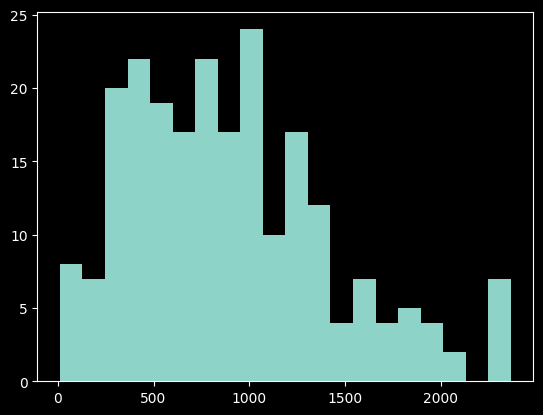

In [105]:
plt.hist(vis_lengths,bins = 20);

In [23]:
len(vis_lengths)

222

In [102]:
bad_fits = np.array([  3,   9,  12,  16,  18,  34,  44,  57,  62,  64,  76,  77,  87,
        98, 100, 102, 111, 113, 118, 123, 124, 136, 137, 154, 161, 181,
       196, 199, 203, 204])

3


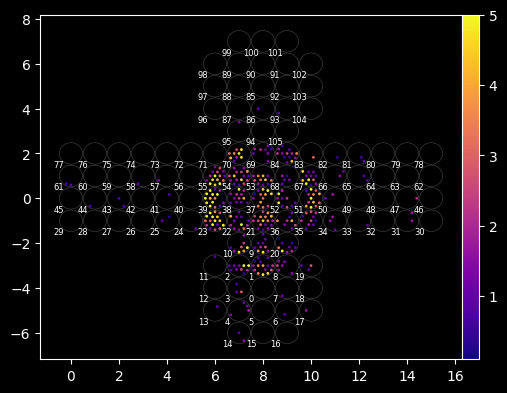

9


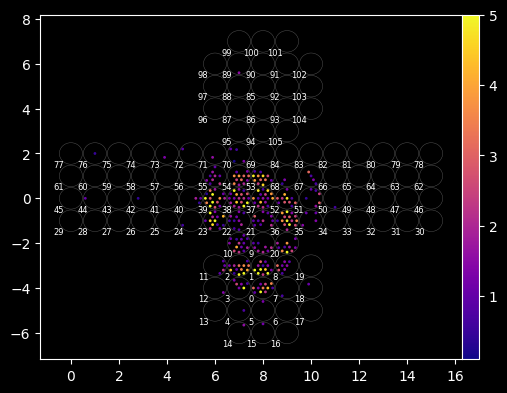

12


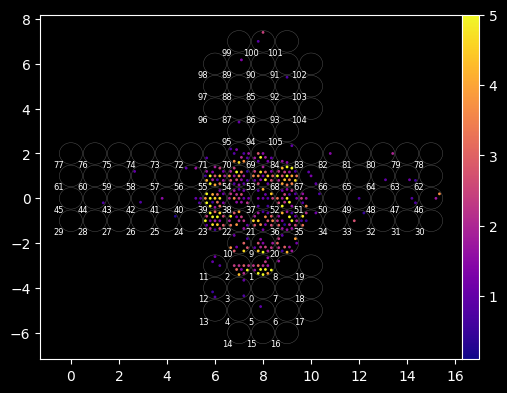

16


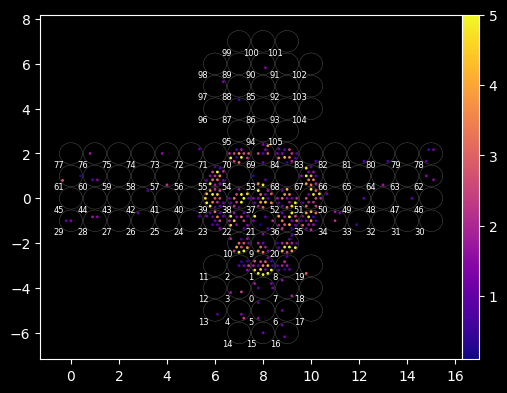

18


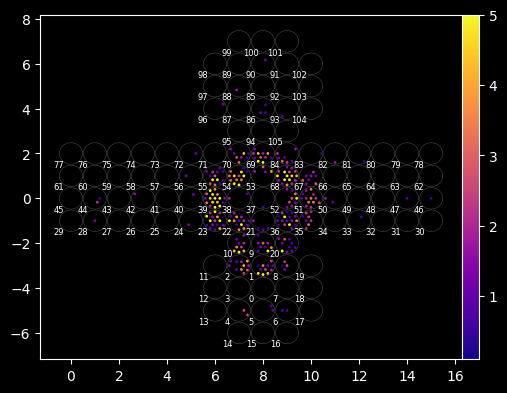

34


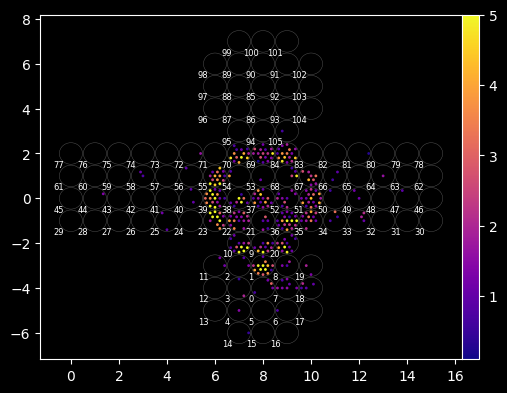

44


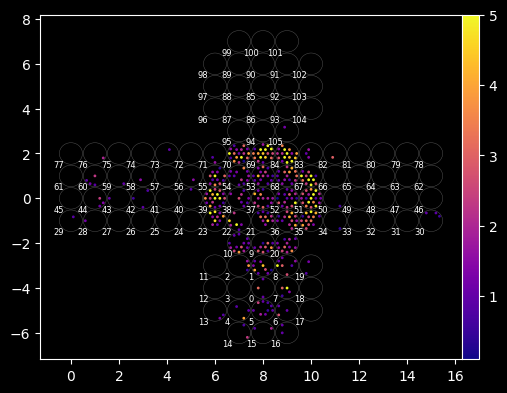

57


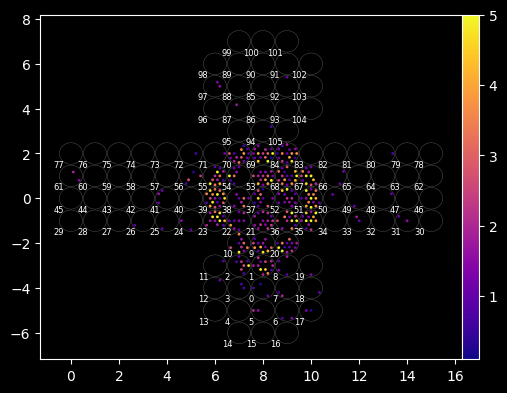

62


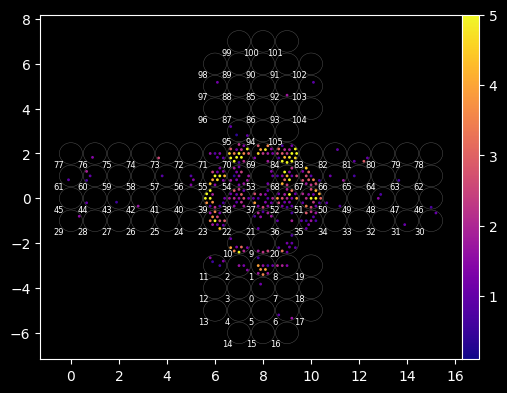

64


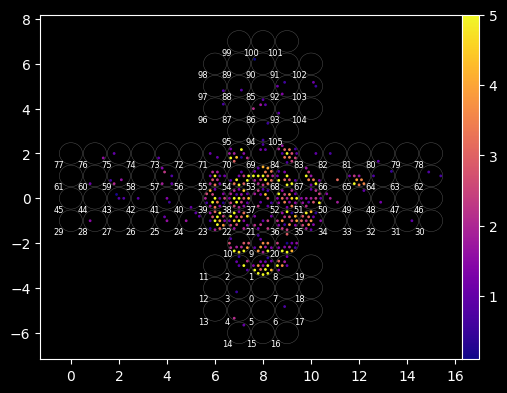

76


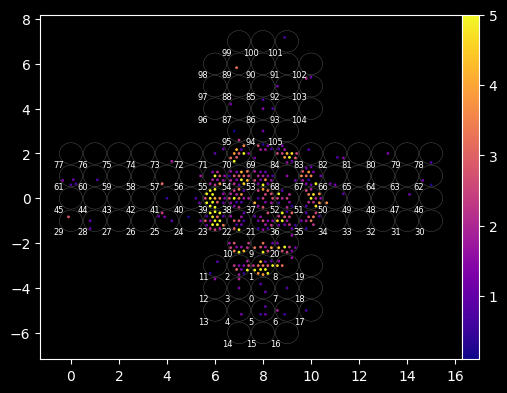

77


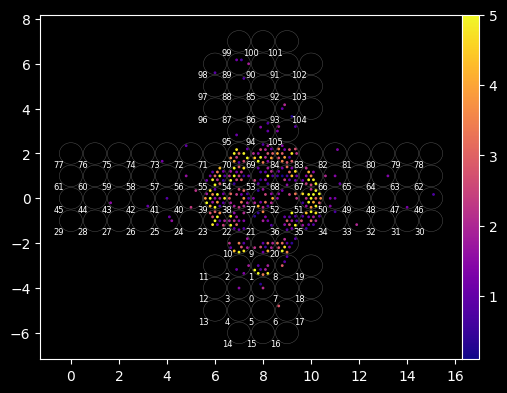

87


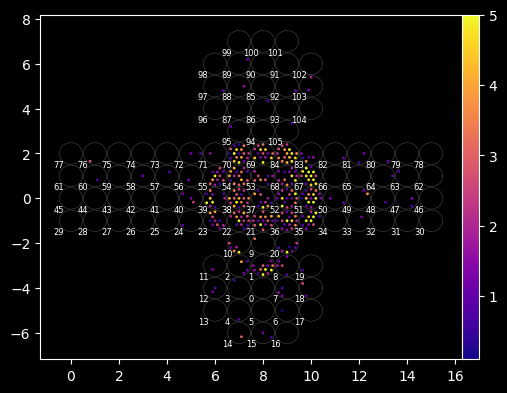

98


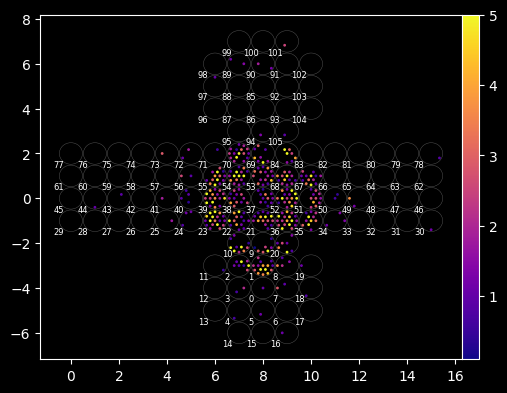

100


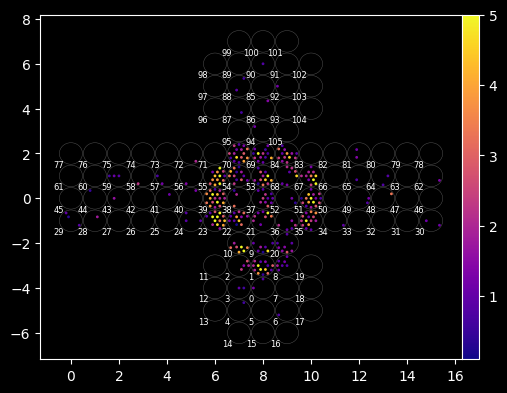

102


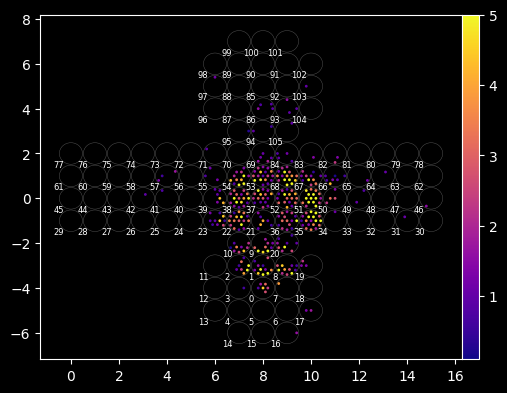

111


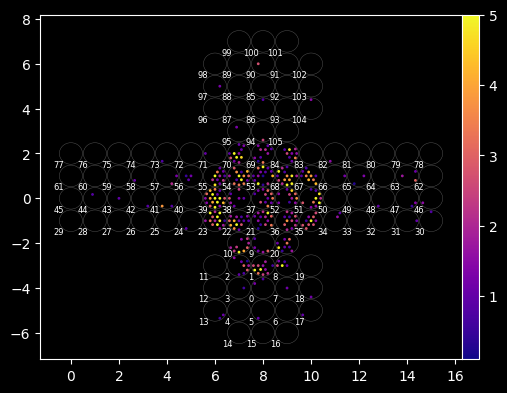

113


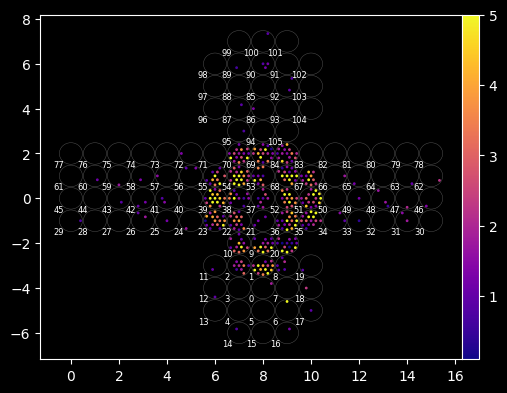

118


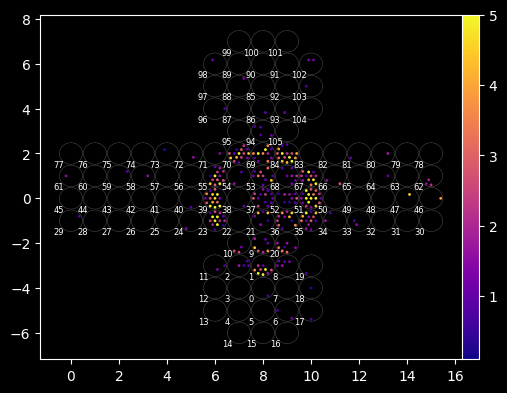

123


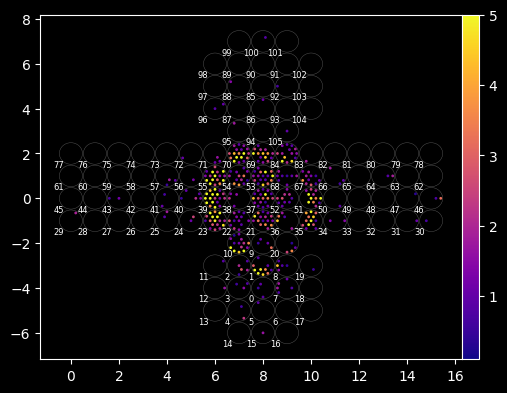

124


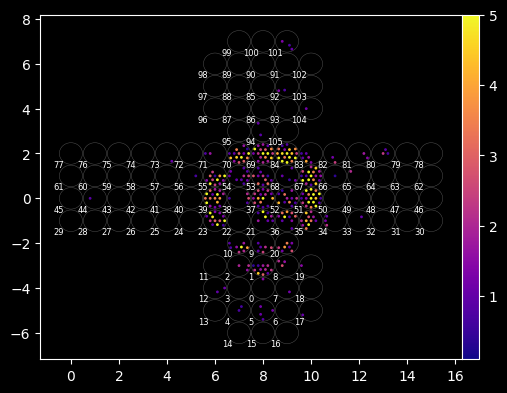

136


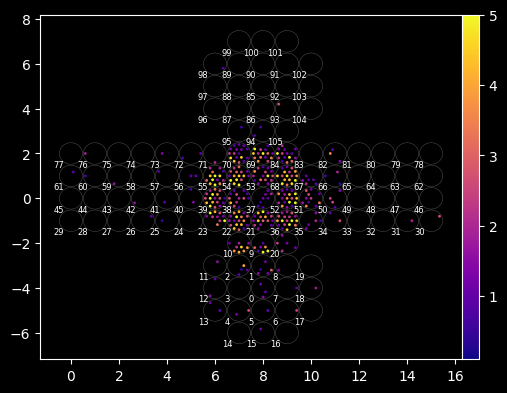

137


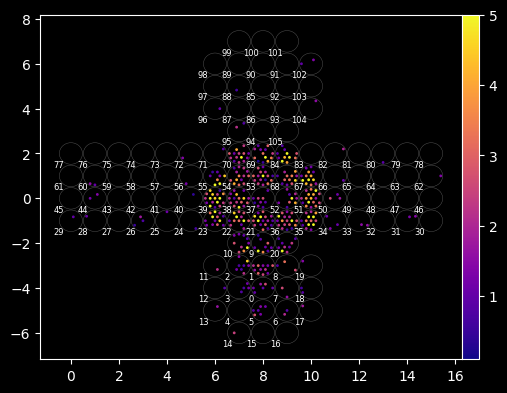

154


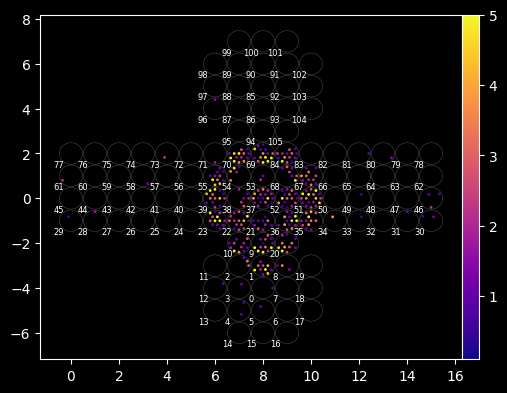

161


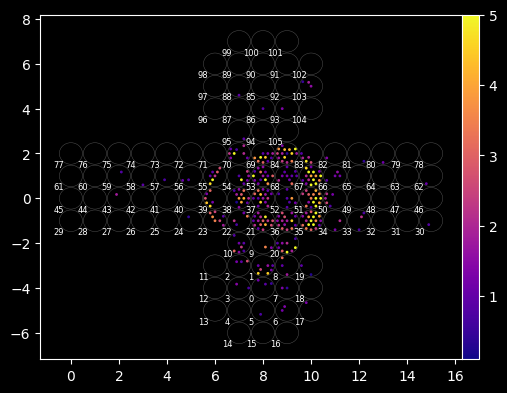

181


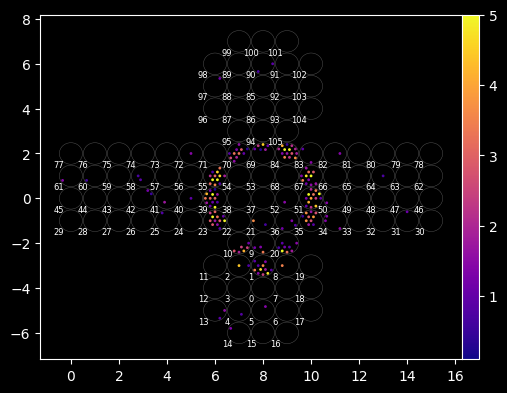

196


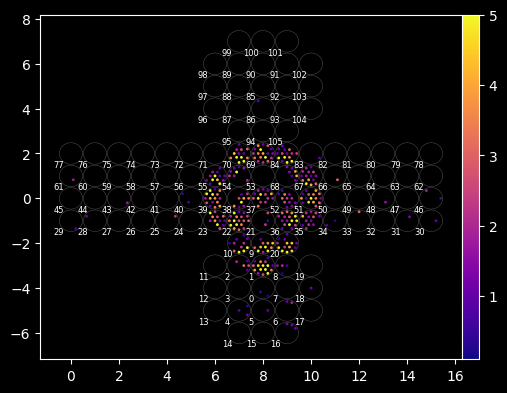

199


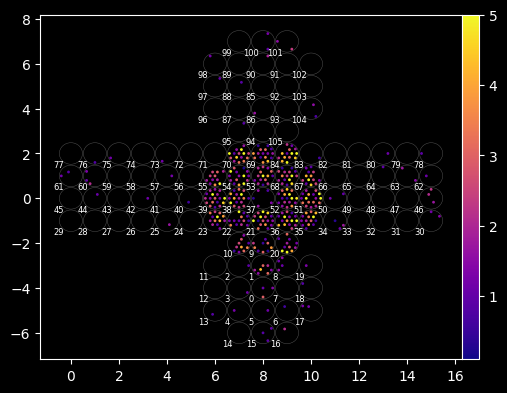

203


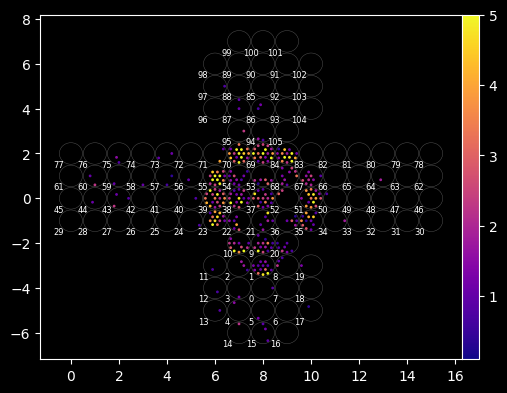

204


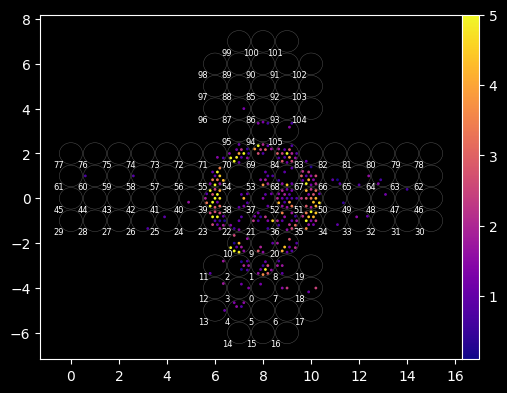

In [103]:
evt_num = 1
cut_time = 17

#for evt_num in range(200):
for evt_num in bad_fits:

    data = {'digi_hit_pmt':[],'digi_hit_time':[],'digi_hit_charge':[]}

    for i in range(len(data_selected['digi_hit_time'][evt_num])):
        if 0<data_selected['digi_hit_time'][evt_num][i]<cut_time:
            wcte_pmt = sim_wcte_mapping[data_selected['digi_hit_pmt'][evt_num][i]+1]

            data['digi_hit_time'].append(data_selected['digi_hit_time'][evt_num][i])
            data['digi_hit_pmt'].append(wcte_pmt)
            data['digi_hit_charge'].append(data_selected['digi_hit_charge'][evt_num][i])

    lf_data = np.array([data['digi_hit_pmt'],data['digi_hit_charge'],data['digi_hit_time']]).T

    print(evt_num)
    plot_event(lf_data,0)

In [53]:
len(data_selected['digi_hit_pmt'])


228

In [22]:
import pickle
with open('./sample_data/wcsim/p+_800MeV_absorptionLike_x0y0zn1348.npz','wb') as f:
    pickle.dump(data_selected,f)
    

In [70]:
d = np.load('./sample_data/wcsim/p+_800MeV_absorptionLike_x0y0zn1348.npz',allow_pickle=True)

In [71]:
d.keys()

dict_keys(['true_hit_pmt', 'true_hit_time', 'digi_hit_pmt', 'digi_hit_time', 'track_start_position', 'track_stop_position', 'track_id', 'track_pid', 'track_start_time', 'track_parent', 'digi_hit_charge', 'position', 'direction', 'energy', 'track_energy', 'track_boundary_kes'])

In [68]:
d.keys()

KeysView(NpzFile '/eos/user/j/jrimmer/sim_work_dir/WCSim/wcsim.npz' with keys: event_id, root_file, pid, position, direction...)